In [ ]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250904_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

df_fixed_variants = pd.read_csv("../results/genome/fixed_variants.csv.gz", compression='gzip')
df_unfixed_variants = pd.read_csv("../results/genome/unfixed_variants.csv.gz", compression='gzip')

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

df_LR_assembly_metadata = pd.read_csv("../data/TRUST.PBAsm.ZA_106CI_AssemblySummary.csv")
df_LR_assembly_metadata['Lineage'] = df_LR_assembly_metadata['Lineage_Asm'].str.replace('lineage', '')

# this keeps only those with NumContigs = 1 and numContigs_Complete = 1 in df_LR_assembly_metadata, and the lineages (Coll2014 exactly) of the LR and SR sequences must match
df_personal_assemblies = pd.read_csv("data/personal_assemblies_samples.tsv", sep='\t', header=None)

df_PacBio_seqs = pd.read_csv("~/MtbLongitudinalDiversity/data/230902.trust.lrandsr.set1to4.106ci.inputwgs.paths.tsv", sep='\t').rename(columns={'SampleID': 'Original_ID'})
df_PacBio_seqs = df_PacBio_seqs.merge(df_trust_patients[['SampleID', 'Original_ID']], on='Original_ID')

F2_thresh = 0.03

In [62]:
df_PacBio_seqs.query("SampleID=='MFS-313'")

,Original_ID,PacBio_FQ_PATH,Illumina_PE_FQs_PATH,Dataset_Tag,SampleID
49,S0305-01,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_Illumi...,TRUST_PB_Set3,MFS-313


In [3]:
df = pd.read_csv("~/MtbLongitudinalDiversity/SplitStrains_pipeline/F2_greater_3percent_samples.tsv", sep='\t', header=None)

In [6]:
df.loc[df[0]=='MFS-313'].to_csv("~/MtbLongitudinalDiversity/SplitStrains_pipeline/F2_greater_3percent_samples_test.tsv", sep='\t', header=None, index=False)

In [387]:
# df_search = pd.read_csv(f"../data/longitudinal_pids_WGS_data.csv")

# for i, row in df_search.iterrows():
#     if not row['Original_ID'].startswith('S'):
        
#         length_numerical = len(row['Original_ID'].split('-')[0])
            
#         newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
#         df_search.loc[i, 'Original_ID'] = newID

In [59]:
df_tbtyper = pd.read_csv("../data/TRUST_TBTypeR_Lineage_Classification_CultureOnly.csv")
df_tbtyper['sample_id'] = df_tbtyper['sample_id'].str.replace('C_', '-').str.replace('_A', '')

In [64]:
df_tbtyper.query("sample_id=='S0305-01'")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,reason
459,S0305-01,2,-1705.474428,0.0001,0,2.667711e-14,31.905,1,125,4.3,0.5746,False,NaN
460,S0305-01,2,-1705.474428,0.0001,0,2.667711e-14,31.905,2,65,2.2.M1.1,0.4254,False,NaN


In [393]:
# len(set(df_trust_patients.Original_ID) - set(df_tbtyper.sample_id))

168

In [392]:
# set(df_tbtyper.sample_id) - set(df_trust_patients.Original_ID)

{'S0194-01', 'S0308-01', 'S0340-01'}

In [439]:
df_tbtyper_mixes = pd.DataFrame(df_tbtyper.query("mix_prop > 0").groupby('sample_id')['mix_phylotype'].nunique()).reset_index().query("mix_phylotype != 1")

In [440]:
F2_mix_samples = list(set(df_search.query("F2 > 0.03").Original_ID.values).intersection(df_tbtyper.sample_id))
len(F2_mix_samples)

22

In [441]:
df_search.query("F2 > 0.03").Original_ID.nunique()

24

In [442]:
set(F2_mix_samples) - set(df_tbtyper_mixes.sample_id)

{'S0152-01', 'S0235-05'}

In [444]:
set(df_tbtyper_mixes.query("sample_id in @df_search.Original_ID").sample_id) - set(F2_mix_samples)

{'S0224-01'}

In [445]:
df_tbtyper.query("sample_id in ['S0224-01']")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,reason
333,S0224-01,2,-442.040878,0.0001,0,0.007011,0.2331,1,40,2.2.M4.4,0.9889,False,NaN
334,S0224-01,2,-442.040878,0.0001,0,0.007011,0.2331,2,65,2.2.M1.1,0.0111,False,NaN


In [446]:
df_search.query("Original_ID in ['S0224-01']")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
292,T0224,S0224-01,MFS-133,1,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.012427,2,1,2


# Get pids without lineage mixing and with lineage concordance at the two timepoints

In [2]:
df_longitudinal_pids = pd.read_csv(f"../data/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_thresh").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

print(f"{len(pids_with_low_F2)}/{df_longitudinal_pids.pid.nunique()} pids have F2 ≤ {F2_thresh} for both samples")

# additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_low_F2").groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.query("pid in @pids_with_same_lineage").groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values

print(f"{len(pids_with_same_lineage)}/{len(pids_with_low_F2)} pids have the same Coll2014 lineages")

df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage").reset_index(drop=True)

299 pids
279/299 pids have F2 ≤ 0.03 for both samples
271/279 pids have the same Coll2014 lineages


# Read in all the low-AF SNP CSV files

In [3]:
lowAF_variant_files = glob.glob(f"{H37Rv_ref_dir}/*/lowAF_SNPs.csv")
len(lowAF_variant_files)

774

In [25]:
df_variants = []

for fName in lowAF_variant_files:
    
    sample_id = os.path.basename(os.path.dirname(fName))
    
    # only get the samples from pids that we can use in the longitudinal analysis
    
    if sample_id in df_longitudinal_pids.SampleID.values:
        df = pd.read_csv(fName)    
        df['SampleID'] = sample_id
        df_variants.append(df.query("REF.str.len() == ALT.str.len()"))
        
df_variants = pd.concat(df_variants)
print(f"{df_variants.SampleID.nunique()} samples")

df_variants['variant'] = df_variants['GENE'] + '_' + df_variants['HGVS_P']
df_variants['variant'] = df_variants['variant'].fillna(df_variants['HGVS_C'])

high_homology_genes = ["clpB", "hsp", "rpoB", "rpoC", "tuf", "rpsC", "aspT", "rrs", "rrl"]

df_variants = df_variants.query("~GENE.str.contains('|'.join(@high_homology_genes))")

# merge with sample-level metadata and pids
df_variants = df_variants.merge(df_longitudinal_pids, on='SampleID').set_index(['pid', 'Original_ID', 'SampleID']).reset_index()

542 samples


In [34]:
min_pos = 0
max_pos = 4411532

df_EBR = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/EBR_Marin.bedgraph", 
                     sep='\t',
                     header=None,
                     names = ['CHROM', 'BEG', 'END', 'EBR']
                    )

df_EBR['CHROM'] = 'Chromosome'

df_exclude = df_EBR.query("EBR < 0.95")[['CHROM', 'BEG', 'END']]

# # add 50 bp to the ends
# df_exclude['BEG'] -= 50
# df_exclude['END'] += 50

# df_exclude.loc[df_exclude['BEG'] < min_pos, 'BEG'] = min_pos
# df_exclude.loc[df_exclude['END'] < min_pos, 'END'] = min_pos

# df_exclude.loc[df_exclude['BEG'] > max_pos, 'BEG'] = max_pos
# df_exclude.loc[df_exclude['END'] > max_pos, 'END'] = max_pos

df_RLC = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.bed",
                     sep='\t',
                     header=None,
                     names = ['CHROM', 'BEG', 'END']
                    )

df_RLC['CHROM'] = 'Chromosome'

pd.concat([df_exclude, df_RLC]).sort_values(['BEG', 'END']).to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None, index=False)




In [63]:
df_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/MFS-100/freebayes/MFS-100.excludeLowConf.csv")
len(df_variants)

1391

In [26]:
df_EBR = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/EBR_Marin.bedgraph", 
                     sep='\t',
                     header=None,
                     names = ['CHROM', 'BEG', 'END', 'EBR']
                    )

df_EBR['CHROM'] = 'Chromosome'

df_exclude = df_EBR.query("EBR < 0.95")[['CHROM', 'BEG', 'END']]

# df_prev_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.bed",
#                               sep='\t',
#                               header=None,
#                               names=['CHROM', 'BEG', 'END']
#                              )

exclude_sites = []

for i, row in df_exclude.iterrows():
    # exclue all sites within 50 bp of the low EBR regions too
    exclude_sites += list(np.arange(row['BEG']-50, row['END']) + 1 + 50)
    
exclude_sites = np.unique(exclude_sites)
num_exclude_sites = df_variants.query("POS in @exclude_sites").POS.nunique()
print(f"Excluding {num_exclude_sites} sites")

Excluding 80 sites


In [27]:
df_variants = df_variants.query("POS not in @exclude_sites").reset_index(drop=True)
assert len(df_variants.iloc[df_variants.index.values[df_variants.duplicated(subset=['SampleID', 'POS'], keep=False)]]) == 0

In [28]:
df_MNPs = df_variants.query("REF.str.len() > 1").reset_index(drop=True)
df_SNPs = df_variants.query("REF.str.len() == 1").reset_index(drop=True)

# all the values that must be duplicated
duplicate_columns = list(set(df_variants.columns) - set(['POS', 'REF', 'ALT']))
    
# helps to control ordering so we know that POS, REF, and ALT are at the end
df_split_MNPs = pd.DataFrame(columns = duplicate_columns + ['POS', 'REF', 'ALT'])
k = 0

for _, row in df_MNPs.iterrows():
    
    split_ref_alleles = list(row['REF'])
    split_alt_alleles = list(row['ALT'])
    
    # need to update the positions
    start = row['POS']
    pos_lst = np.arange(start, start + len(row['REF']))
    
    for i, (ref, alt) in enumerate(zip(split_ref_alleles, split_alt_alleles)):
        
        # some could be the same because the MNP includes both changed and unchanged sites
        if ref != alt:
            df_split_MNPs.loc[k, :] = [row[col] for col in duplicate_columns] + [pos_lst[i], ref, alt]
            k += 1

len(df_split_MNPs)

9861

In [29]:
df_variants_split_MNPs = pd.concat([df_SNPs, df_split_MNPs]).sort_values(['pid', 'Sampling_Week', 'POS']).reset_index(drop=True)
assert len(df_variants_split_MNPs.iloc[df_variants_split_MNPs.index.values[df_variants_split_MNPs.duplicated(subset=['SampleID', 'POS'], keep=False)]]) == 0

df_variants_split_MNPs['SNP'] = df_variants_split_MNPs['POS'].astype(str) + '_' + df_variants_split_MNPs['REF'] + '-' + df_variants_split_MNPs['ALT']

df_variants_split_MNPs['LowCov'].value_counts(dropna=False)

LowCov
0    530206
1      1138
Name: count, dtype: int64

In [30]:
len(df_variants_split_MNPs)

531344

In [31]:
# exclude_lowCov_variants = {}

# for pid in df_variants_split_MNPs.pid.unique():
    
#     variants_lst_1 = df_variants_split_MNPs.query("pid==@pid & LowCov==1 & Paired_Sample_Num==1").SNP.unique()
#     variants_lst_2 = df_variants_split_MNPs.query("pid==@pid & LowCov==1 & Paired_Sample_Num==2").SNP.unique()
    
#     non_overlapping_lowCov_variants = list(set(variants_lst_1).symmetric_difference(variants_lst_2))
    
#     # add to dataframe of variants to exclude per pid
#     if len(non_overlapping_lowCov_variants) > 0:
#         exclude_lowCov_variants[pid] = non_overlapping_lowCov_variants
        
#         # remove them from the dataframe
#         df_variants_split_MNPs = df_variants_split_MNPs.query("~(pid == @pid & SNP in @non_overlapping_lowCov_variants)")
        
# # print(len(df_variants_split_MNPs))

# # then remove all remaining cases where LowCov == 1. At this point, each case of LowCov should also have LowCov for that same variant in the other sample for a given pid
# df_variants_split_MNPs = df_variants_split_MNPs.query("LowCov != 1")
# del df_variants_split_MNPs['LowCov']

# assert len(df_variants_split_MNPs.iloc[df_variants_split_MNPs.index.values[df_variants_split_MNPs.duplicated(subset=['SampleID', 'POS'], keep=False)]]) == 0

# # then save
# df_variants_split_MNPs.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/longitudinal_SNPs.csv.gz", compression='gzip', index=False)

df_variants_split_MNPs = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/longitudinal_SNPs.csv.gz", compression='gzip')

In [8]:
# def get_matrices_of_variants(df_variants, col_name, binarize_fixed_variants=False, fixed_thresh=0.95, absent_thresh=0.05):

#     # first check that every pid has 2 and only 2 samples
#     assert len(df_variants.drop_duplicates(['pid', 'SampleID']).groupby('pid').SampleID.nunique().unique()) == 1
#     assert df_variants.drop_duplicates(['pid', 'SampleID']).groupby('pid').SampleID.nunique().unique()[0] == 2
    
#     # get all samples and variants so that we can add in zeros if needed
#     all_variants = df_variants.sort_values('POS')[col_name].unique()
#     all_samples = df_variants.pid.unique() 
        
#     sample_1_variants = df_variants.query("Paired_Sample_Num==1").pivot(index='pid', columns=col_name, values='AF').fillna(0)

#     # add in any missing indels
#     sample_1_variants = sample_1_variants.merge(pd.DataFrame(columns = list(set(all_variants) - set(sample_1_variants.columns)), index=sample_1_variants.index.values).fillna(0), left_index=True, right_index=True)

#     # add in any missing samples
#     sample_1_variants = pd.concat([sample_1_variants, pd.DataFrame(columns = all_variants, index=list(set(all_samples) - set(sample_1_variants.index.values))).fillna(0)])
    
#     # ensure same row and column ordering
#     sample_1_variants = sample_1_variants.loc[all_samples, all_variants]
        
#     if binarize_fixed_variants:
#         # replace fixed variant AFs with 1
#         sample_1_variants[sample_1_variants >= fixed_thresh] = 1
        
#     # these shouldn't be there because we kept only unfixed variants with AF >= 0.05, but check anyway
#     sample_1_variants[sample_1_variants < absent_thresh] = 0
    
#     sample_2_variants = df_variants.query("Paired_Sample_Num==2").pivot(index='pid', columns=col_name, values='AF').fillna(0)

#     sample_2_variants = sample_2_variants.merge(pd.DataFrame(columns = list(set(all_variants) - set(sample_2_variants.columns)), index=sample_2_variants.index.values).fillna(0), left_index=True, right_index=True)

#     sample_2_variants = pd.concat([sample_2_variants, pd.DataFrame(columns = all_variants, index=list(set(all_samples) - set(sample_2_variants.index.values))).fillna(0)])

#     sample_2_variants = sample_2_variants.loc[all_samples, all_variants]

#     assert sample_1_variants.shape[1] == sample_2_variants.shape[1]

#     if binarize_fixed_variants:
#         sample_2_variants[sample_2_variants >= fixed_thresh] = 1

#     sample_2_variants[sample_2_variants < absent_thresh] = 0

#     # remove variants that are fixed in every sample (probably some issue in variant calling :( )
#     variants_fixed_high_proportion = []

#     for col in sample_1_variants.columns:

#         if len(sample_1_variants.loc[sample_1_variants[col] >= 0.9]) / len(sample_1_variants) >= 0.90:
#             variants_fixed_high_proportion.append(col)

#     print(f"{sample_1_variants.shape[0]} samples with {sample_1_variants.shape[1] - len(variants_fixed_high_proportion)} variants")

#     return sample_1_variants.drop(variants_fixed_high_proportion, axis=1).astype(float), sample_2_variants.drop(variants_fixed_high_proportion, axis=1).astype(float)

In [135]:
# # previously, 271 x 11,239
# sample_1_variants, sample_2_variants = get_matrices_of_variants(df_variants_split_MNPs, 'SNP')
# SNP_differences = sample_2_variants - sample_1_variants

# sample_1_variants.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/sample_1_variants.csv.gz", compression='gzip')
# sample_2_variants.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/sample_2_variants.csv.gz", compression='gzip')
# SNP_differences.to_csv("/n/data1/hms/dbmi/farhat/Sanjana/SNP_differences.csv.gz", compression='gzip')

271 samples with 11193 variants


In [5]:
# df_variants_split_MNPs = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/longitudinal_SNPs.csv.gz", compression='gzip')

# sample_1_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/sample_1_variants.csv.gz", compression='gzip', index_col=[0])
# sample_2_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/sample_2_variants.csv.gz", compression='gzip', index_col=[0])
# SNP_differences = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/SNP_differences.csv.gz", compression='gzip', index_col=[0])

In [9]:
# change_thresh = 0.05

# df_num_change_variants = pd.DataFrame(columns = ['pid', 'Gain_SNP', 'Lose_SNP']).set_index('pid')

# for pid in SNP_differences.index.values:
#     df_num_change_variants.loc[pid, :] = [len(SNP_differences.T.query(f"{pid} > @change_thresh")), len(SNP_differences.T.query(f"{pid} < -@change_thresh"))]
    
# df_num_change_variants['Net'] = df_num_change_variants['Gain_SNP'] - df_num_change_variants['Lose_SNP']

# df_num_change_variants = df_num_change_variants.merge(df_longitudinal_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage']].drop_duplicates(), left_index=True, right_on='pid')

In [10]:
# sns.stripplot(data=df_num_change_variants,
#              x='Lineage',
#               order=[2, 3, 4],
#               y='Net',
#              hue='Lineage',
#              # multiple='dodge',
#              # common_norm=False,
#              # stat='probability'
#             )

# sns.despine()
# plt.show()

In [447]:
# previously median = 0 and mean = 0.27
# median and mean number of variants with a change of at least 0.05 in AF
# df_num_change_variants.Net.median(), df_num_change_variants.Net.mean()

(0.0, 0.2730627306273063)

In [17]:
# df_num_change_variants.groupby('Lineage')['Net'].agg(['mean', 'median'])

In [18]:
# df_num_change_variants.sort_values('Net', ascending=True).head()

In [19]:
# df_num_change_variants.sort_values('Net', ascending=False).head()

In [20]:
# pid = 'T0067'

# gain_variants = SNP_differences.T.query(f"{pid} > @change_thresh").index.values

# SNP_differences.T.query(f"{pid} > @change_thresh").sort_values(pid)[pid]

In [21]:
# lose_variants = SNP_differences.T.query(f"{pid} < -@change_thresh").index.values

# SNP_differences.T.query(f"{pid} < -@change_thresh").sort_values(pid)[pid]

In [17]:
AF_lst = np.linspace(0.05, 0.9, 51)

df_test = pd.DataFrame({'AF': AF_lst})
df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

In [18]:
df_test

,AF,variable,value
0,0.050,Product,0.047500
1,0.067,Product,0.062511
2,0.084,Product,0.076944
3,0.101,Product,0.090799
4,0.118,Product,0.104076
...,...,...,...
148,0.832,Shannon_Entropy,0.653109
149,0.849,Shannon_Entropy,0.612337
150,0.866,Shannon_Entropy,0.568307
151,0.883,Shannon_Entropy,0.520676


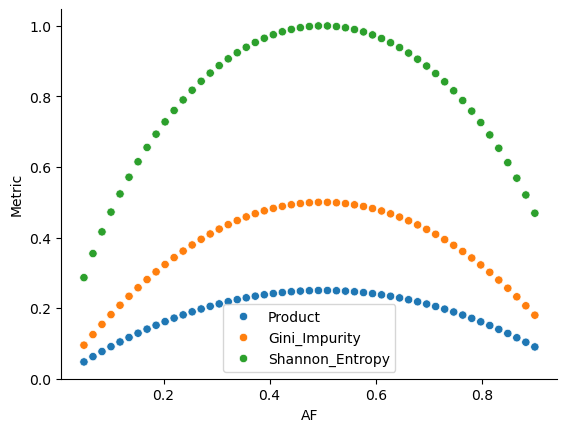

In [20]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable'
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Metric')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
# plt.savefig("../results/figures/AF_product_example.svg")

In [ ]:
def add_gene_annotations(df):
    
    assert 'SNP' in df.columns
    
    df['POS'] = df['SNP'].str.split('_').str[0].astype(int)
    df['Gene'] = df['POS'].map(h37Rv_coords_dict)

    df = df.merge(h37Rv_genes[['Symbol', 'Strand', 'Start', 'End']].rename(columns={'Symbol': 'Gene'}), how='left')

    df.loc[df['Strand']=='+', 'Dist_Start'] = df['POS'] - df['Start']
    df.loc[df['Strand']=='-', 'Dist_Start'] = df['End'] - df['POS']

    df['Length'] = np.abs(df['End'] - df['Start']) + 1
    
    return df


df_variants_split_MNPs = add_gene_annotations(df_variants_split_MNPs)

# suspicious. Idk how to filter them out. Maybe the SNP density filter?
df_variants_split_MNPs = df_variants_split_MNPs.query("GENE not in ['Rv2081c', 'Rv2082']")

In [251]:
# get all unfixed SNPs. Exclude sites that are above 90% AF in both samples
unfixed_SNP_matrix = []

fixed_AF_thresh = 0.90

for pid in df_variants_split_MNPs.pid.unique():

    # for each pid, keep only the variants that are present in both and look at AF changes in those. Lots of unreliability currently in variants found in 
    # one sample but not the other. In some cases, they get filtered out, and in others they don't
    # or maybe we can keep them for now, but in the next step, keep only variants with an unfixed SNP. 
    # there are a lot of unreliable highly fixed SNPs.
    single_pid_matrix = df_variants_split_MNPs.query("pid==@pid").pivot(index='Paired_Sample_Num', columns='SNP', values='AF')#.dropna(axis=1, how='any')
    
    # then require that there is at least one unfixed AF for each variant. Otherwise we get bogged down looking at tiny differences
    # like AF = 0.94 vs. AF = 0.99, which is usually just due to mis mapping reads bringing down the AF
    # still interesting to look at unfixed variants that remain unfixed, so don't include the second part requiring max AF > 0.75
    lower_AF = pd.DataFrame(single_pid_matrix.min(axis=0))
    lower_AF.columns = ['AF']
    
    # only keep variants that have an unfixed AF somewhere
    keep_variants = lower_AF.query("AF <= @fixed_AF_thresh").index.values
    
#     higher_AF = pd.DataFrame(single_pid_matrix.max(axis=0))
#     higher_AF.columns = ['AF']
#     keep_variants = set(lower_AF.query("AF <= @fixed_AF_thresh").index).intersection(higher_AF.query("AF > 0.75").index)

    single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)
    
    unfixed_SNP_matrix.append(single_pid_matrix[keep_variants])
    
unfixed_SNP_matrix = pd.concat(unfixed_SNP_matrix).fillna(0)
print(unfixed_SNP_matrix.shape)

sample_1_SNPs = unfixed_SNP_matrix.loc[unfixed_SNP_matrix.index.str.endswith('_1')]
sample_2_SNPs = unfixed_SNP_matrix.loc[unfixed_SNP_matrix.index.str.endswith('_2')]

# remove the suffixes from the indexes
sample_1_SNPs.index = sample_1_SNPs.index.str.split('_').str[0]
sample_2_SNPs.index = sample_2_SNPs.index.str.split('_').str[0]

SNP_differences = sample_2_SNPs - sample_1_SNPs
print(SNP_differences.shape)

(542, 1057)
(271, 1057)


In [ ]:
def LAF_metric(lowAF_array):
    
    LAF = 0

    for i, AF in enumerate(lowAF_array):

        LAF += AF * (1 - AF)

    return LAF / len(lowAF_array)

In [356]:
df_LAF = pd.DataFrame(columns = ['pid', 'LAF1', 'LAF2'])

for i, pid in enumerate(sample_1_SNPs.index.values):
    sample_1_ND = compute_LAF_metric(sample_1_SNPs.loc[pid].values)
    sample_2_ND = compute_LAF_metric(sample_2_SNPs.loc[pid].values)
    
    df_LAF.loc[i, :] = [pid, sample_1_ND, sample_2_ND]
    
df_LAF['Diff'] = df_LAF['LAF2'] - df_LAF['LAF1']
df_LAF['Abs_Diff'] = np.abs(df_LAF['LAF2'] - df_LAF['LAF1'])

In [357]:
st.wilcoxon(df_LAF['LAF1'],
            df_LAF['LAF2'],
            alternative='less'
           )

WilcoxonResult(statistic=13253.0, pvalue=0.0026660235580831283)

In [358]:
st.ttest_rel(df_LAF['LAF1'],
            df_LAF['LAF2'],
            alternative='less'
           )

TtestResult(statistic=-1.9860164712840647, pvalue=0.024021322910879054, df=270)

In [255]:
print("Medians")

for col in df_LAF.columns:
    if col != 'pid':
        print(f"    {col}: {df_LAF[col].median()}")
        
print("Means")

for col in df_LAF.columns:
    if col != 'pid':
        print(f"    {col}: {df_LAF[col].mean()}")

Medians
    LAF1: 0.00042473268690904027
    LAF2: 0.00045873448777165036
    Diff: 0.0001538840989247864
Means
    LAF1: 0.00046554089770350156
    LAF2: 0.0005109709862485708
    Diff: 0.0002467752564892396


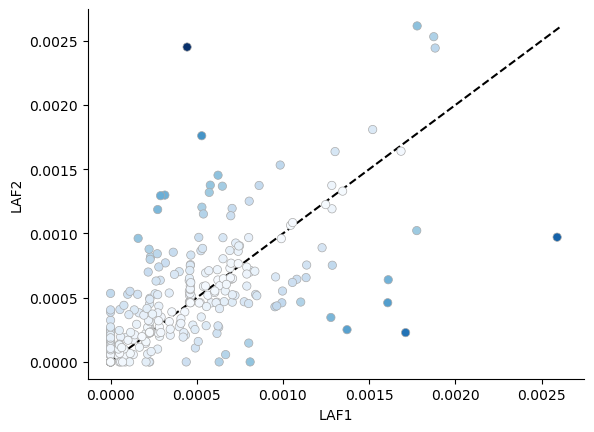

In [359]:
sns.scatterplot(data=df_LAF,
                x='LAF1',
                y='LAF2',
                # alpha=0.75,
                hue='Abs_Diff',
                palette='Blues',
                edgecolor='darkgray',
                legend=False
               )

# can't do because lots of 0s and we care about outliers
# plt.xscale('log')
# plt.yscale('log')

# # 2D density estimation
# sns.kdeplot(
#     data=df_LAF,
#     x="LAF1", 
#     y="LAF2",
#     fill=True,   # shaded density
#     cmap="viridis", # colormap
#     thresh=0,    # draw the full range
#     levels=100   # smoother gradient
# )


sns.despine()

# Add 45-degree line
lims = [
    np.min([df_LAF['LAF1'].min(), df_LAF['LAF2'].min()]),
    np.max([df_LAF['LAF1'].max(), df_LAF['LAF2'].max()])
]
plt.plot(lims, lims, color='black', linestyle='--', zorder=0)  # dashed line

plt.savefig("../results/figures/LAF_changes.svg", bbox_inches='tight')

In [365]:
# LAF changes substantially
df_LAF.query("Abs_Diff > 0.001").sort_values(['LAF1', 'Diff'], ascending=[False, True])

,pid,LAF1,LAF2,Diff,Abs_Diff
92,T0151,0.00259,0.000971,-0.001619,0.001619
46,T0067,0.001711,0.000228,-0.001483,0.001483
269,T0475,0.001607,0.000461,-0.001147,0.001147
246,T0439,0.001371,0.000251,-0.00112,0.00112
176,T0288,0.000529,0.00176,0.001232,0.001232
65,T0106,0.000444,0.002451,0.002007,0.002007
142,T0236,0.00029,0.001294,0.001004,0.001004


In [362]:
# LAF remains high across both timepoints
df_LAF.query("Abs_Diff < 0.0006 & LAF1 > 0.0015").sort_values(['LAF1', 'Abs_Diff'], ascending=[False, True]).sort_values('pid')

,pid,LAF1,LAF2,Diff,Abs_Diff
181,T0294,0.001685,0.00164,-0.000044,0.000044
190,T0324,0.00152,0.001809,0.000289,0.000289
221,T0381,0.001883,0.002443,0.00056,0.00056


In [366]:
pid = 'T0151'
print(df_longitudinal_pids.query("pid==@pid").sort_values('Paired_Sample_Num').SampleID.values)

search_SNPs = df_variants_split_MNPs.query("pid==@pid & AF <= @fixed_AF_thresh").sort_values(['SNP', 'Paired_Sample_Num']).SNP.unique()

df_search = pd.DataFrame(SNP_differences.loc[pid, search_SNPs]).reset_index()

df_search = df_search.merge(df_variants_split_MNPs[['POS', 'REF', 'ALT', 'SNP', 'GENE', 'Start', 'End', 'Dist_Start', 'Length']].drop_duplicates(), on='SNP')

['MFS-606' 'MFS-607']


In [347]:
# df_plot = df_search.merge(df_variants_split_MNPs.query("pid==@pid & SNP in @search_SNPs")[['SNP', 'AF', 'Paired_Sample_Num']], on='SNP').sort_values(['POS', 'Paired_Sample_Num'])

# df_plot[['SNP', 'AF', 'Paired_Sample_Num']].pivot(index='Paired_Sample_Num', columns='SNP', values='AF')

In [368]:
df_plot = unfixed_SNP_matrix.loc[[f"{pid}_1", f"{pid}_2"]].T
df_plot.columns = ['Sample1', 'Sample2']
df_plot = df_plot.query("~(Sample1==0 & Sample2==0)")

df_plot['Diff'] = df_plot['Sample2'] - df_plot['Sample1']
df_plot['Abs_Diff'] = np.abs(df_plot['Sample2'] - df_plot['Sample1'])

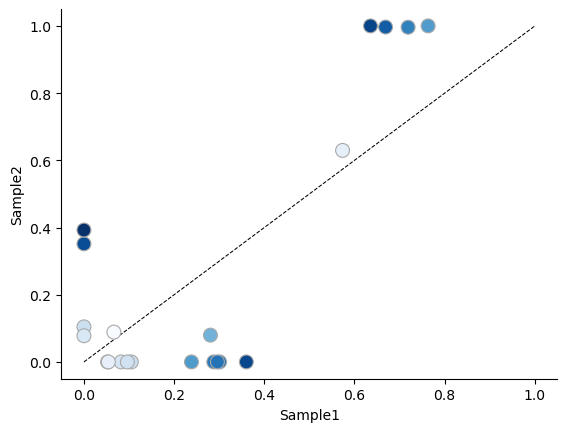

In [369]:
sns.scatterplot(data=df_plot,
                x='Sample1',
                y='Sample2',
                hue='Abs_Diff',
                palette='Blues',
                edgecolor='darkgray',
                legend=False,
                s=100
               )

# Add 45-degree line
lims = [
    np.min([df_plot['Sample1'].min(), df_plot['Sample2'].min()]),
    np.max([df_plot['Sample1'].max(), df_plot['Sample2'].max()])
]
plt.plot(lims, lims, color='black', linestyle='--', zorder=0, linewidth=0.75)  # dashed line

sns.despine()
plt.show()
# plt.savefig(f"../results/figures/{pid}_lowAF_change.svg", bbox_inches='tight')

In [350]:
pd.concat([df_plot.query("Diff > 0.2").merge(df_search, left_index=True, right_on='SNP').sort_values('POS'),
           df_plot.query("Sample1 > 0.6 & Diff < 0.2").merge(df_search, left_index=True, right_on='SNP').sort_values('POS')
          ]).sort_values('POS')

,Sample1,Sample2,Diff,SNP,T0381,POS,REF,ALT,GENE,Start,End,Dist_Start,Length
0,0.087500,0.607143,0.519643,102375_C-T,0.519643,102375,C,T,ctpA,100583.0,102868.0,1792.0,2286.0
9,0.118388,0.563353,0.444965,559757_G-A,0.444965,559757,G,A,fadB2-umaA,NaN,NaN,NaN,NaN
10,0.138095,0.584967,0.446872,690426_G-A,0.446872,690426,G,A,mce2C,689059.0,690504.0,1367.0,1446.0
11,0.135802,0.582677,0.446875,845278_C-T,0.446875,845278,C,T,mmsA,844421.0,845953.0,675.0,1533.0
1,0.203125,0.000000,0.203125,1172920_A-G,-0.203125,1172920,A,G,Rv1050,1172881.0,1173786.0,39.0,906.0
3,0.133333,0.582011,0.448677,1370836_A-C,0.448677,1370836,A,C,Rv1227c-lpqX,NaN,NaN,NaN,NaN
5,0.628647,0.582931,0.045716,2592310_G-A,-0.045716,2592310,G,A,Rv2319c,2591848.0,2592726.0,416.0,879.0
8,0.128302,0.627160,0.498859,4217145_C-G,0.498859,4217145,C,G,hisC2,4217134.0,4218195.0,11.0,1062.0


In [353]:
pos_lst = pd.concat([df_plot.query("Diff > 0.2").merge(df_search, left_index=True, right_on='SNP').sort_values('POS'),
           df_plot.query("Sample1 > 0.6 & Diff < 0.2").merge(df_search, left_index=True, right_on='SNP').sort_values('POS')
          ]).POS.unique()

print_str = 'bcftools filter -i "'

for pos in pos_lst:
    print_str += f'POS == {pos} | '
    
print_str = print_str.strip('| ') + '"'
print_str

'bcftools filter -i "POS == 102375 | POS == 559757 | POS == 690426 | POS == 845278 | POS == 1172920 | POS == 1370836 | POS == 4217145 | POS == 2592310"'

In [63]:
pid = 'T0106'

search_SNPs = df_variants_split_MNPs.query("pid==@pid & AF <= @fixed_AF_thresh")[['Paired_Sample_Num', 'POS', 'REF', 'ALT', 'AF', 'SNP']].sort_values(['SNP', 'Paired_Sample_Num']).SNP.values

In [70]:
df_search = pd.DataFrame(SNP_differences.loc[pid, search_SNPs]).reset_index()

df_search = add_gene_annotations(df_search)

In [75]:
df_longitudinal_pids.query("pid==@pid")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
130,T0106,106-01,MFS-56,1,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0.010525,4,1,2
131,T0106,106-08,MFS-57,8,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0.008982,4,2,2


In [74]:
df_search.sort_values(pid)

,SNP,T0106,POS,Gene,Strand,Start,End,Dist_Start,Length
13,4107799_A-G,-0.861419,4107799,acs,+,4107792.0,4109747.0,7.0,1956.0
12,3640843_T-C,-0.757202,3640843,fbiA,+,3640543.0,3641538.0,300.0,996.0
10,3515941_G-A,-0.254181,3515941,nuoF,+,3515412.0,3516749.0,529.0,1338.0
6,2515197_G-A,-0.251880,2515197,aceE,+,2512539.0,2515244.0,2658.0,2706.0
8,3108676_G-A,-0.235849,3108676,Rv2800,+,3108416.0,3110065.0,260.0,1650.0
5,2503607_C-A,-0.218121,2503607,Rv2230c,-,2503469.0,2504608.0,1001.0,1140.0
9,3477617_C-A,-0.127717,3477617,NC_2397,NaN,NaN,NaN,NaN,NaN
7,276061_C-T,-0.058020,276061,fadE4,+,276058.0,277764.0,3.0,1707.0
14,4328030_C-G,0.060976,4328030,ethR,+,4327549.0,4328199.0,481.0,651.0
4,2368863_C-T,0.241791,2368863,NC_1636,NaN,NaN,NaN,NaN,NaN


In [78]:
df_personal_assemblies.loc[df_personal_assemblies[0].isin(['MFS-56', 'MFS-57'])]

,0,1,2
87,MFS-56,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...
88,MFS-57,/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_per...,/n/data1/hms/dbmi/farhat/mm774/DownloadedData/...


In [84]:
sample = 'MFS-57'

df_ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv").drop_duplicates()
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")

lowAF_variants_bothCoords = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None)
# df_ground_truth['GeneName'] = df_ground_truth['POS'].map(h37Rv_coords_dict)

In [87]:
df_ground_truth.query("POS==3608283")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
10,3608283,G,A,6.364580e-14,NaN,234,137,97.0,0.41453,59.9897,...,49,88,33.0,64.0,27.1184,24.5235,11.0918,3.15295,39.0,58.0


In [85]:
confusion_matrix

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result
0,143219.0,G,C,143219,G,C,TP
1,207176.0,C,T,207176,C,T,TP
2,720755.0,C,T,720755,C,T,TP
3,1791049.0,C,T,1791049,C,T,TP
4,2223736.0,G,A,2223736,G,A,TP
5,2368863.0,C,T,2368863,C,T,TP
6,2503607.0,A,C,2503607,A,C,TP
7,2515197.0,A,G,2515197,A,G,TP
8,3108676.0,A,G,3108676,A,G,TP
9,3515941.0,A,G,3515941,A,G,TP


In [82]:
lowAF_variants_bothCoords#.loc[lowAF_variants_bothCoords[1]==3608282]

,0,1,2,3,4,5
0,Chromosome,720754,720755,S0106-01_contig_1_pilon_725213_725214,0,+
1,Chromosome,976896,976898,S0106-01_contig_1_pilon_980553_980555,0,+
2,Chromosome,3232536,3232537,S0106-01_contig_1_pilon_3237627_3237628,0,+
3,Chromosome,3477616,3477617,S0106-01_contig_1_pilon_3484530_3484531,0,+
4,Chromosome,3640842,3640843,S0106-01_contig_1_pilon_3646877_3646878,0,+
5,Chromosome,1096664,1096665,S0106-01_contig_1_pilon_1100348_1100349,0,+
6,Chromosome,1634537,1634538,S0106-01_contig_1_pilon_1639112_1639113,0,+
7,Chromosome,1634546,1634547,S0106-01_contig_1_pilon_1639121_1639122,0,+
8,Chromosome,4107798,4107799,S0106-01_contig_1_pilon_4108240_4108241,0,+
9,Chromosome,1638124,1638125,S0106-01_contig_1_pilon_1642687_1642688,0,+


In [ ]:
AF_values = sample_1_SNPs.loc['T0004'].fillna(0).values
hist, bin_edges = np.histogram(AF_values, bins=bins)

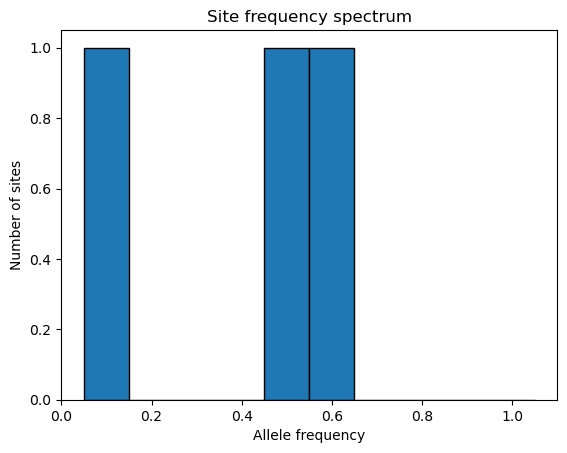

In [509]:
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge", edgecolor="black")
plt.xlabel("Allele frequency")
plt.ylabel("Number of sites")
plt.title("Site frequency spectrum")
plt.show()

In [58]:
df_analyze_changes = pd.DataFrame(SNP_differences.sum(axis=0).sort_values()).reset_index()
df_analyze_changes.columns = ['SNP', 'Sum_AF_change']

df_analyze_changes = add_gene_annotations(df_analyze_changes)

In [59]:
change_thresh = 0.05
gain = True

df_analyze_changes.loc[(df_analyze_changes['Sum_AF_change'] >= change_thresh) | (df_analyze_changes['Sum_AF_change'] <= -change_thresh)]

,SNP,Sum_AF_change,POS,Gene,Strand,Start,End,Dist_Start,Length
0,3296843_A-G,-3.884659,3296843,pks15,-,3296350.0,3297840.0,997.0,1491.0
1,3717219_C-T,-2.167594,3717219,sugI,+,3717090.0,3718598.0,129.0,1509.0
2,3717105_C-T,-1.704831,3717105,sugI,+,3717090.0,3718598.0,15.0,1509.0
3,549637_G-A,-1.590495,549637,NC_365,NaN,NaN,NaN,NaN,NaN
4,3449952_G-A,-1.374606,3449952,Rv3083,+,3448504.0,3449991.0,1448.0,1488.0
...,...,...,...,...,...,...,...,...,...
1064,1733439_C-T,0.914676,1733439,Rv1532c,-,1733116.0,1733550.0,111.0,435.0
1065,2062820_C-T,0.916667,2062820,bacA,-,2062809.0,2064728.0,1908.0,1920.0
1066,2624701_T-G,0.922511,2624701,Rv2345,+,2623821.0,2625803.0,880.0,1983.0
1067,4046309_A-G,0.924051,4046309,Rv3604c,-,4046303.0,4047496.0,1187.0,1194.0


In [326]:
# variant 3296843_A-G is getting an artificially low AF by freebayes. pilon is better for that
variant = '4390707_C-G'

change_thresh = 0.05

gain = True

if gain:
    search_pids = SNP_differences.loc[SNP_differences[variant] >= change_thresh][variant].index.values
else:
    search_pids = SNP_differences.loc[SNP_differences[variant] <= -change_thresh][variant].index.values

In [330]:
SNP_differences[variant].dropna()

Paired_Sample_Num
T0466   -0.004652
Name: 4390707_C-G, dtype: object

In [327]:
df_variants_split_MNPs.query("SNP==@variant & pid in @search_pids").sort_values(['pid', 'Sampling_Week'])[['pid', 'SampleID', 'Sampling_Week', 'SNP', 'AF', 'Lineage']]

,pid,SampleID,Sampling_Week,SNP,AF,Lineage


In [253]:
acs_gene = h37Rv_seq.seq[4107792-1:4109747]
acs_protein = acs_gene.translate()
len(acs_gene), len(acs_protein)

(1956, 652)

In [251]:
# A > G in the first sample, then revert to mostly A in the second
acs_gene[7]

'A'

In [266]:
mutated_acs_gene = list(acs_gene)
mutated_acs_gene[7] = 'G'
mutated_acs_gene = Seq.Seq(''.join(mutated_acs_gene))

# missense mutation. Starts off G (glycine), then reverts to E (glutamic acid), which is H37Rv
mutated_acs_protein = mutated_acs_gene.translate()

In [268]:
acs_protein

Seq('VSESTPEVSSSYPPPAHFAEHANARAELYREAEEDRLAFWAKQANRLSWTTPFT...AK*')

In [267]:
mutated_acs_protein

Seq('VSGSTPEVSSSYPPPAHFAEHANARAELYREAEEDRLAFWAKQANRLSWTTPFT...AK*')

In [244]:
df_annot = pd.read_csv("/n/data1/hms/dbmi/farhat/huaming/mtb_regulartoryVariants/WGS/ChinerOms_2019/resistance_predictions/N1177.mm2.Flye_I3_PP_AssemblyToH37rv.paftools_variants_annot.tsv", sep='\t')

In [ ]:
df_pred = pd.read_csv("")

In [245]:
df_annot.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
22,761109,G,T,NaN,60.0,False,NaN,NaN,NaN,NaN,missense_variant,rpoB,c.1303G>T,p.Asp435Tyr,rpoB_p.Asp435Tyr,Rifampicin,1) Assoc w R


In [246]:
# os.listdir("/n/data1/hms/dbmi/farhat/huaming/mtb_regulartoryVariants/WGS/ChinerOms_2019/resistance_predictions")

In [152]:
df_longitudinal_pids.query("pid=='T0445'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
494,T0445,S0445-01,MFS-824,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008292,2,1,2
495,T0445,S0445-08,MFS-825,8,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.009102,2,2,2


In [101]:
sample = 'MFS-155'
fName = f"{H37Rv_ref_dir}/{sample}/lowAF_SNPs.csv"
sample_id = os.path.basename(os.path.dirname(fName))
    
df = pd.read_csv(fName)    
df['SampleID'] = sample_id

In [102]:
df.query("POS==1711556")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,RPPR,RPL,RPR,ANN,GENE,EFFECT,HGVS_C,HGVS_P,LowCov,SampleID
485,1711556,G,C,252.056,NaN,10,0,10.0,1.0,60.0,...,0.0,0.0,10.0,['C|missense_variant|MODERATE|Rv1520|Rv1520|tr...,Rv1520,missense_variant,c.529G>C,p.Asp177His,0,MFS-155


In [123]:
df_depth.query("POS==1711556")

,CHROM,POS,COV,COV_RIGHT_ROLLING_AVG,COV_LEFT_ROLLING_AVG
1711555,Chromosome,1711556,12,0.12,458.08


In [11]:
df_longitudinal_pids.query("pid=='T0244'")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
296,T0244,244-01,MFS-154,1,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.010024,3,1,2
297,T0244,244-04,MFS-155,4,3.1.1,3.1.1.i1,"east_african_indian,ghana,mungi",NaN,NaN,0.011144,3,2,2


In [14]:
df_depth.query("POS==1084911")

,CHROM,POS,COV,COV_RIGHT_ROLLING_AVG,COV_LEFT_ROLLING_AVG
1084910,Chromosome,1084911,137,261.71,264.14


In [28]:
df_depth.query("POS >= 1084900 & POS <= 1084920")

,CHROM,POS,COV,COV_RIGHT_ROLLING_AVG,COV_LEFT_ROLLING_AVG
1084899,Chromosome,1084900,169,291.15,293.78
1084900,Chromosome,1084901,149,288.35,291.15
1084901,Chromosome,1084902,150,285.63,288.35
1084902,Chromosome,1084903,139,282.80,285.63
1084903,Chromosome,1084904,140,280.04,282.80
1084904,Chromosome,1084905,133,277.22,280.04
1084905,Chromosome,1084906,132,274.40,277.22
1084906,Chromosome,1084907,132,271.70,274.40
1084907,Chromosome,1084908,131,268.99,271.70
1084908,Chromosome,1084909,137,266.57,268.99


In [26]:
1084911 in valleys[0], 1084911 in left_low_cov_sites

(False, False)

In [22]:
valleys = scipy.signal.find_peaks(-df_depth['COV'])

In [25]:
valleys[0]

array([     80,      85,      88, ..., 4411442, 4411445, 4411450])

In [12]:
sample = 'MFS-155'
df_depth = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz", compression='gzip', sep='\t', header=None, names=['CHROM', 'POS', 'COV'])

window_size = 100
df_depth['COV_RIGHT_ROLLING_AVG'] = df_depth['COV'].rolling(window=window_size, min_periods=1, closed='right').mean()
df_depth['COV_LEFT_ROLLING_AVG'] = df_depth['COV'].rolling(window=window_size, min_periods=1, closed='left').mean()

# low_cov_sites = df_depth.query("COV < @coverage_min").POS.unique()

# exclude sites where the coverage drops to less than 1/2 the rolling average. Means we're at a valley or something
right_low_cov_sites = df_depth.loc[df_depth['COV'] < df_depth['COV_RIGHT_ROLLING_AVG'] / 2].POS.values
left_low_cov_sites = df_depth.loc[df_depth['COV'] < df_depth['COV_LEFT_ROLLING_AVG'] / 2].POS.values


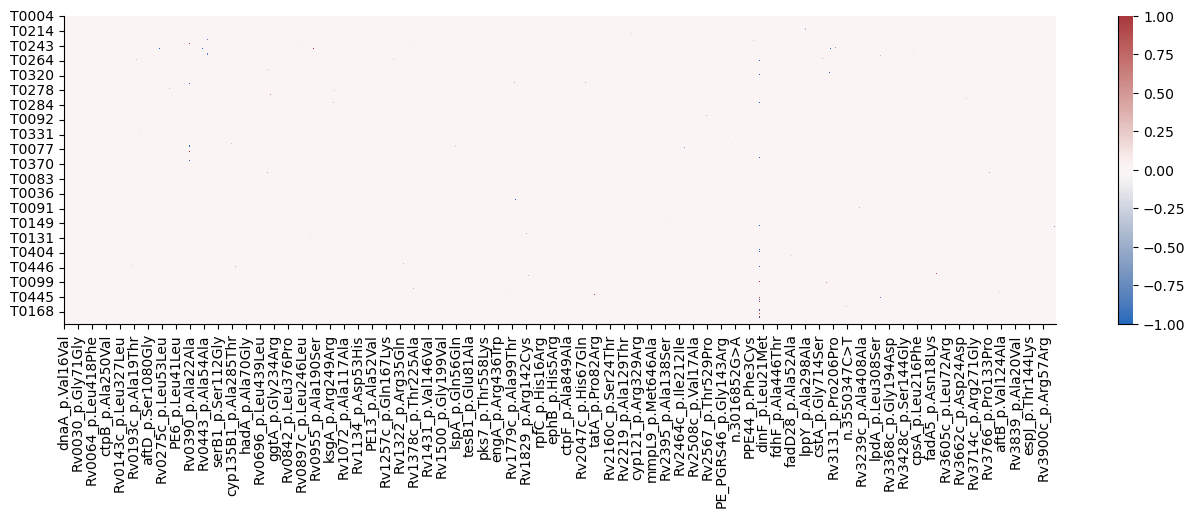

In [348]:
fig, ax = plt.subplots(figsize=(16, ))

sns.heatmap(SNP_differences,
            cmap='vlag',
            cbar=True,
            ax=ax
           )

sns.despine()
plt.show()

In [134]:
df_variants.query("variant in ['n.1742G>A', 'n.1849C>A', 'n.1977A>G']")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'AO', 'DP']]

,pid,SampleID,POS,REF,ALT,AF,AO,DP
0,T0004,MFS-1,1849,C,A,1.0,363.0,363
1,T0004,MFS-1,1977,A,G,1.0,351.0,351
1170,T0021,MFS-10,1742,G,A,1.0,435.0,435
1171,T0021,MFS-10,1977,A,G,1.0,407.0,407
1861,T0004,MFS-2,1849,C,A,1.0,386.0,386
1862,T0004,MFS-2,1977,A,G,1.0,353.0,353
3030,T0021,MFS-9,1742,G,A,1.0,420.0,420
3031,T0021,MFS-9,1977,A,G,1.0,361.0,361


In [136]:
df_variants.query("Paired_Sample_Num==1").SampleID.unique()

array(['MFS-1', 'MFS-9'], dtype=object)

In [135]:
df_variants.query("Paired_Sample_Num==2").SampleID.unique()

array(['MFS-10', 'MFS-2'], dtype=object)

In [127]:
df_longitudinal_pids.query("pid in ['T0004', 'T0021']")

,pid,Original_ID,SampleID,Sampling_Week,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples
4,T0004,04-01,MFS-1,1,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008274,2,1,2
5,T0004,04-08,MFS-2,8,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.007192,2,2,2
22,T0021,21-01,MFS-9,1,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,0.008449,4,1,2
23,T0021,21-07,MFS-10,7,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,0.008721,4,2,2


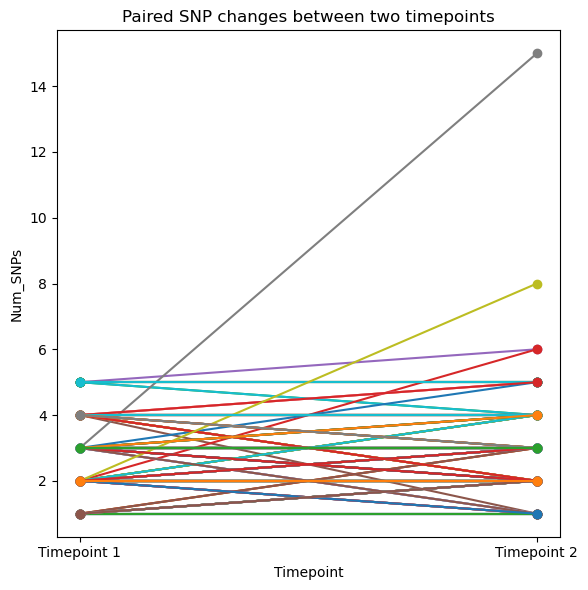

In [65]:
pids = np.sort(df_plot.sort_values("Change").pid.unique())

plt.figure(figsize=(6,6))

for pid in pids:
    subset = df_plot[df_plot["pid"] == pid]
    # Extract x (time point) and y (Num_SNPs)
    x = subset["Paired_Sample_Num"]
    y = subset["Num_SNPs"]
    plt.plot(x, y, marker='o', linestyle='-', label=pid)  # line connecting paired points

# Optional: adjust x-axis ticks
plt.xticks([1,2], ["Timepoint 1", "Timepoint 2"])
plt.xlabel("Timepoint")
plt.ylabel("Num_SNPs")
plt.title("Paired SNP changes between two timepoints")

# Optional: remove legend if too many samples
# plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()